Célula 1: Instalar/importar bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix

Célula 2: Upload do dataset

In [2]:
from google.colab import files

uploaded = files.upload()

Saving heart.csv to heart (1).csv


Célula 3: Ler dataset

In [3]:
df = pd.read_csv('heart.csv', delimiter=',', skipinitialspace=True)

print(df.head())

   idade  sexo  tipo_de_dor_no_peito  pressao_arterial_em_repouso  colesterol  \
0     63     1                     3                          145         233   
1     37     1                     2                          130         250   
2     41     0                     1                          130         204   
3     56     1                     1                          120         236   
4     57     0                     0                          120         354   

   glicemia_em_jejum  eletrocardiograma_em_repouso  \
0                  1                             0   
1                  0                             1   
2                  0                             0   
3                  0                             1   
4                  0                             1   

   frequencia_cardiaca_maxima  angina_induzida_por_exercicio  depressao_st  \
0                         150                              0           2.3   
1                         187   

Célula 4: Separar variáveis

In [11]:
x = df.drop(['doenca_cardiaca'], axis=1)
y = df.doenca_cardiaca.values

Célula 5: Padronização dos dados

In [5]:
scaler = StandardScaler().fit(x)
standardX = scaler.transform(x)

Célula 6: Dividir treino e teste

In [6]:
x_train, x_test, y_train, y_test = train_test_split(
    standardX,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Célula 7: Grid Search + Naive Bayes

In [7]:
param_grid_nb = {
    'var_smoothing': np.logspace(0, -9, num=100)
}

grid_nb = GridSearchCV(
    estimator=GaussianNB(),
    param_grid=param_grid_nb,
    verbose=0,
    cv=5,
    scoring='accuracy'
)

grid_nb.fit(x_train, y_train)

melhor_nb = grid_nb.best_estimator_

Célula 8: Fazer previsões

In [8]:
previsoes = melhor_nb.predict(x_test)

acuracia_teste = melhor_nb.score(x_test, y_test) * 100

matriz = confusion_matrix(y_test, previsoes)

Célula 9: Matriz de confusão

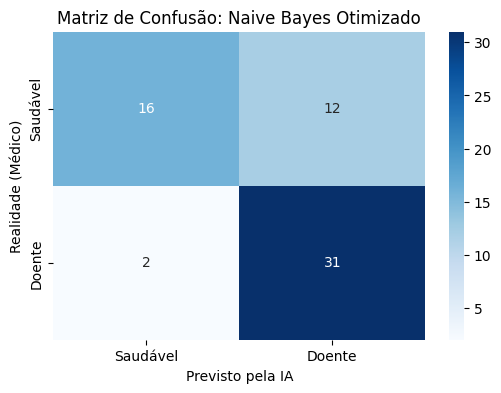

In [9]:
plt.figure(figsize=(6,4))

sns.heatmap(
    matriz,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Saudável', 'Doente'],
    yticklabels=['Saudável', 'Doente']
)

plt.xlabel('Previsto pela IA')
plt.ylabel('Realidade (Médico)')
plt.title('Matriz de Confusão: Naive Bayes Otimizado')

plt.show()

Célula 10: Relatório técnico

In [10]:
print("\n" + "="*60)
print(f"{'RELATÓRIO TÉCNICO: NAIVE BAYES (PYTHON)':^60}")
print("="*60)

print(f"\n[CONFIGURAÇÃO DO MODELO]")
print(f"Melhor parâmetro 'var_smoothing' encontrado: {grid_nb.best_params_['var_smoothing']}")
print(f"Acurácia média na Validação Cruzada: {grid_nb.best_score_:.4f}")

print(f"\n[DESEMPENHO NO TESTE]")
print(f"Acurácia Geral: {acuracia_teste:.2f}%")

print("\nMatriz de Confusão:")

df_cm = pd.DataFrame(
    matriz,
    index=['Real: Saudável', 'Real: Doente'],
    columns=['Previsto: Saudável', 'Previsto: Doente']
)

print("-" * 60)
print(df_cm)
print("-" * 60)

print("\nRelatório de Métricas Detalhadas:")

print(
    classification_report(
        y_test,
        previsoes,
        target_names=['Saudável (0)', 'Doente (1)']
    )
)

print("="*60)


          RELATÓRIO TÉCNICO: NAIVE BAYES (PYTHON)           

[CONFIGURAÇÃO DO MODELO]
Melhor parâmetro 'var_smoothing' encontrado: 1.0
Acurácia média na Validação Cruzada: 0.8309

[DESEMPENHO NO TESTE]
Acurácia Geral: 77.05%

Matriz de Confusão:
------------------------------------------------------------
                Previsto: Saudável  Previsto: Doente
Real: Saudável                  16                12
Real: Doente                     2                31
------------------------------------------------------------

Relatório de Métricas Detalhadas:
              precision    recall  f1-score   support

Saudável (0)       0.89      0.57      0.70        28
  Doente (1)       0.72      0.94      0.82        33

    accuracy                           0.77        61
   macro avg       0.80      0.76      0.76        61
weighted avg       0.80      0.77      0.76        61

